<a href="https://colab.research.google.com/github/lord-of-the-strings/Data-Science/blob/main/uhi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip uhi.zip
!mkdir -p data
!mv ahmedabad_NDVI.tif data/
!mv ahmedabad_LST.tif data/
!ls

Archive:  uhi.zip
  inflating: download.py             
  inflating: process.py              
  inflating: plot.py                 
  inflating: README.md               
mv: cannot stat 'uhi.csv': No such file or directory
data  download.py  plot.py  process.py	README.md  sample_data	uhi.zip


In [ ]:
!pip install rasterio geemap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 56.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import rasterio
from sklearn.preprocessing import StandardScaler
import torch

def load_single_day_map(file_path):
    """Opens a tiff file, handles missing data, and returns a 2D numpy array."""
    with rasterio.open(file_path) as src:
        data = src.read(1).astype(np.float32)
        nodata = src.nodata

        # Create a mask for valid pixels (no clouds, no edge blanks)
        valid_mask = (data != nodata) & (~np.isnan(data)) if nodata is not None else ~np.isnan(data)

        # Clean data: Replace invalid values with 0 or NaN temporarily
        data[~valid_mask] = np.nan
        return data, valid_mask

lst_grid, valid_lst = load_single_day_map('data/ahmedabad_LST.tif')
ndvi_grid, valid_ndvi = load_single_day_map('data/ahmedabad_NDVI.tif')

# Combine masks to find pixels where BOTH LST and NDVI are good
complete_valid_mask = valid_lst & valid_ndvi

# We fit the scaler only on valid data points
scaler = StandardScaler()
ndvi_valid_flat = ndvi_grid[complete_valid_mask].reshape(-1, 1)
ndvi_scaled_flat = scaler.fit_transform(ndvi_valid_flat)

# Reconstruct a scaled 2D grid for NDVI, filling invalid spaces with 0
ndvi_grid_scaled = np.zeros_like(ndvi_grid)
ndvi_grid_scaled[complete_valid_mask] = ndvi_scaled_flat.flatten()

In [ ]:
# Convert our 2D grids into PyTorch Tensors
# Shape: (1, 1, Height, Width) - adding batch and channel dimensions for tracking neighbors
X_tensor = torch.tensor(ndvi_grid_scaled).unsqueeze(0).unsqueeze(0)
Y_true_tensor = torch.tensor(np.nan_to_num(lst_grid, nan=0.0)).unsqueeze(0).unsqueeze(0)
mask_tensor = torch.tensor(complete_valid_mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

print("Input X Shape:", X_tensor.shape)
print("Target Y Shape:", Y_true_tensor.shape)

Input X Shape: torch.Size([1, 1, 1014, 1014])
Target Y Shape: torch.Size([1, 1, 1014, 1014])


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
def get_spatial_physics_loss(predictions, mask):
    """
    Calculates the spatial variance (Laplacian) of predicted LST.
    Penalizes extreme pixel-to-pixel jumps to ensure spatial heat continuity.
    """
    # Define a standard Laplace kernel to find spatial gradients
    laplacian_kernel = torch.tensor([[[[0.0,  1.0, 0.0],
                                       [1.0, -4.0, 1.0],
                                       [0.0,  1.0, 0.0]]]], device=predictions.device)

    # Calculate spatial second derivatives
    spatial_gradients = F.conv2d(predictions, laplacian_kernel, padding=1)

    # Square the gradients and only calculate loss on valid pixels
    squared_gradients = spatial_gradients ** 2
    valid_gradients = squared_gradients * mask

    return torch.sum(valid_gradients) / torch.sum(mask)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.checkpoint import checkpoint  # Import memory optimizer

class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout_rate=0.2):
        super(ResidualBlock, self).__init__()
        self.bn = nn.BatchNorm2d(channels)
        self.activation = Swish()
        self.conv = nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=1)
        self.dropout = nn.Dropout2d(p=dropout_rate)

    def forward(self, x):
        # We define a custom function inside to allow checkpointing memory saves
        def _forward_block(out):
            out = self.bn(out)
            out = self.activation(out)
            out = self.conv(out)
            out = self.dropout(out)
            return out

        # Checkpoint cuts memory usage drastically by trading it for a tiny bit of CPU/GPU recalculation time
        return x + checkpoint(_forward_block, x, use_reentrant=False)

class LST_PINN_Model(nn.Module):
    # Reduced hidden_channels from 512 to 128 to dramatically clear RAM space
    def __init__(self, input_channels=1, hidden_channels=128, num_blocks=6, dropout_rate=0.2):
        super(LST_PINN_Model, self).__init__()
        self.input_layer = nn.Conv2d(in_channels=input_channels, out_channels=hidden_channels, kernel_size=1)
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(channels=hidden_channels, dropout_rate=dropout_rate) for _ in range(num_blocks)]
        )
        self.output_layer = nn.Conv2d(in_channels=hidden_channels, out_channels=1, kernel_size=1)

    def forward(self, x):
        out = self.input_layer(x)
        out = self.res_blocks(out)
        return self.output_layer(out)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import gc
from sklearn.metrics import r2_score

# 1. Immediate Hardware Flush
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using execution device: {device}")

# 2. Get 1D indices of the valid city pixels natively
# This uses almost zero RAM compared to building a massive tabular matrix
valid_y, valid_x = np.where(complete_valid_mask)
total_pixels = len(valid_y)

# Create a deterministic random split across the indices (80% train, 20% test)
np.random.seed(42)
shuffled_indices = np.random.permutation(total_pixels)
split_idx = int(total_pixels * 0.8)

train_indices = shuffled_indices[:split_idx]
test_indices = shuffled_indices[split_idx:]

# 3. Streamlined 1D Feed-Forward Architecture
class TabularLSTModel(nn.Module):
    def __init__(self):
        super(TabularLSTModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model = TabularLSTModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-6)
criterion = nn.MSELoss()

# 4. On-the-Fly Batch Generation Loop
# Instead of moving a giant matrix to the GPU, we compile tiny batches on the fly
BATCH_SIZE = 4096
epochs = 60  # Reduced epochs for an agile, quick validation run
H_img, W_img = lst_grid.shape

print(f"Total valid pixels: {total_pixels:,} | Training on: {len(train_indices):,}")
print("Training memory-safe streaming model...")

for epoch in range(1, epochs + 1):
    model.train()
    np.random.shuffle(train_indices) # Shuffle training pointers
    epoch_loss = 0.0

    for i in range(0, len(train_indices), BATCH_SIZE):
        optimizer.zero_grad()

        # Pick a small batch of pixel coordinate pointers
        batch_idx = train_indices[i : i + BATCH_SIZE]

        # Extract features dynamically from the 2D source grids
        b_y = valid_y[batch_idx]
        b_x = valid_x[batch_idx]

        b_ndvi = ndvi_grid_scaled[b_y, b_x].reshape(-1, 1)
        b_norm_y = (b_y / (H_img - 1)).reshape(-1, 1)
        b_norm_x = (b_x / (W_img - 1)).reshape(-1, 1)

        # Combine into a small batch tensor
        batch_x_np = np.hstack([b_ndvi, b_norm_x, b_norm_y])
        batch_y_np = lst_grid[b_y, b_x].reshape(-1, 1)

        if batch_x_np.shape[0] <= 1:
            continue

        # Push only this tiny batch to the active execution device
        X_batch_t = torch.tensor(batch_x_np, dtype=torch.float32).to(device)
        Y_batch_t = torch.tensor(batch_y_np, dtype=torch.float32).to(device)

        predictions = model(X_batch_t)
        loss = criterion(predictions, Y_batch_t)

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch_idx)

    # Evaluate every 10 epochs using a memory-safe test streaming loop
    if epoch % 10 == 0 or epoch == 1:
        model.eval()
        test_preds = []
        test_trues = []

        with torch.no_grad():
            for j in range(0, len(test_indices), BATCH_SIZE):
                t_idx = test_indices[j : j + BATCH_SIZE]
                t_y, t_x = valid_y[t_idx], valid_x[t_idx]

                t_ndvi = ndvi_grid_scaled[t_y, t_x].reshape(-1, 1)
                t_norm_y = (t_y / (H_img - 1)).reshape(-1, 1)
                t_norm_x = (t_x / (W_img - 1)).reshape(-1, 1)

                t_x_np = np.hstack([t_ndvi, t_norm_x, t_norm_y])
                t_y_np = lst_grid[t_y, t_x].reshape(-1, 1)

                X_t_tensor = torch.tensor(t_x_np, dtype=torch.float32).to(device)
                preds = model(X_t_tensor).cpu().numpy().flatten()

                test_preds.append(preds)
                test_trues.append(t_y_np.flatten())

        val_r2 = r2_score(np.concatenate(test_trues), np.concatenate(test_preds))
        print(f"Epoch [{epoch}/{epochs}] -> Train Loss: {epoch_loss / len(train_indices):.4f} | Test R²: {val_r2:.4f}")

Using execution device: cuda
Total valid pixels: 972,920 | Training on: 778,336
Training memory-safe streaming model...
Epoch [1/60] -> Train Loss: 1653.2395 | Test R²: -91.5514
Epoch [10/60] -> Train Loss: 3.9407 | Test R²: 0.5881
Epoch [20/60] -> Train Loss: 3.7729 | Test R²: 0.6147
Epoch [30/60] -> Train Loss: 3.6393 | Test R²: 0.6134
Epoch [40/60] -> Train Loss: 3.5317 | Test R²: 0.6523
Epoch [50/60] -> Train Loss: 3.4263 | Test R²: 0.6074
Epoch [60/60] -> Train Loss: 3.3772 | Test R²: 0.6761


Reconstructing full city map image from 972,920 active pixels...
          AHMEDABAD LST MODEL POC REPORT          
Total Spatial Pixels Processed : 972,920
Overall Model R² Score         : 0.6766
Root Mean Square Error (RMSE)  : 1.85°C
Mean Absolute Error (MAE)      : 1.41°C


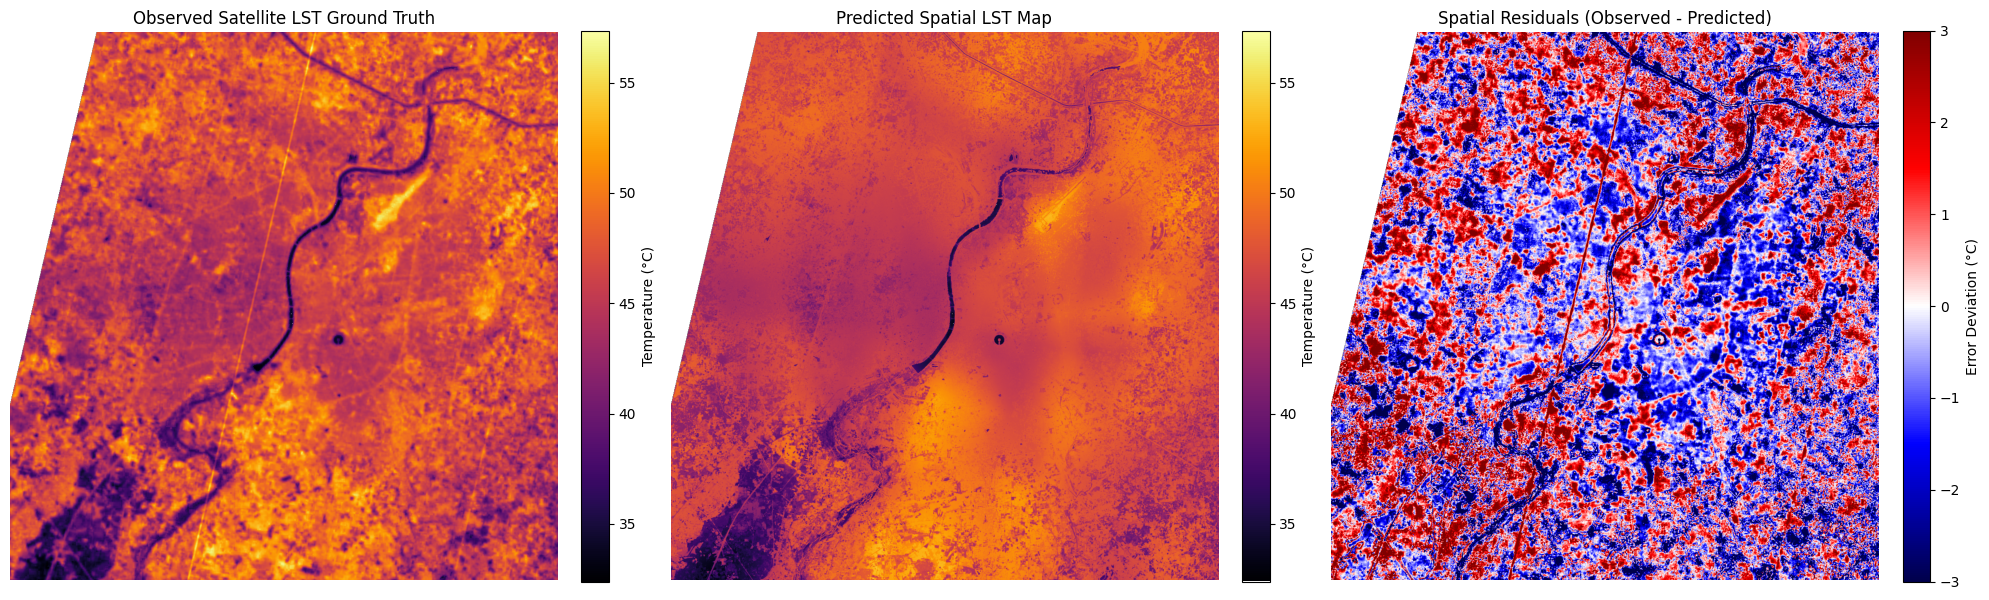

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Ensure the model is in evaluation mode
model.eval()

# 2. Memory-Safe Reconstitution Strategy
# Build an empty template grid filled with NaNs matching the original dimensions
lst_predicted_grid = np.full((H_img, W_img), np.nan, dtype=np.float32)
predictions_list = []
true_values_list = []

print(f"Reconstructing full city map image from {total_pixels:,} active pixels...")

with torch.no_grad():
    for k in range(0, total_pixels, BATCH_SIZE):
        p_idx = shuffled_indices[k : k + BATCH_SIZE]
        p_y, p_x = valid_y[p_idx], valid_x[p_idx]

        # Stream features out of the existing 2D source grids
        p_ndvi = ndvi_grid_scaled[p_y, p_x].reshape(-1, 1)
        p_norm_y = (p_y / (H_img - 1)).reshape(-1, 1)
        p_norm_x = (p_x / (W_img - 1)).reshape(-1, 1)

        # Pack them into a temporary mini-batch array
        p_x_np = np.hstack([p_ndvi, p_norm_x, p_norm_y])
        p_y_true = lst_grid[p_y, p_x]

        X_p_tensor = torch.tensor(p_x_np, dtype=torch.float32).to(device)
        preds = model(X_p_tensor).cpu().numpy().flatten()

        # Map the predictions directly back into their exact 2D coordinates
        lst_predicted_grid[p_y, p_x] = preds

        predictions_list.append(preds)
        true_values_list.append(p_y_true)

# Stitch flat lists together for the metrics block
all_preds = np.concatenate(predictions_list)
all_trues = np.concatenate(true_values_list)

# Clean up a version of observed data for visual comparison
lst_observed_clean = lst_grid.copy()
lst_observed_clean[~complete_valid_mask] = np.nan
spatial_residuals = lst_observed_clean - lst_predicted_grid

# =====================================================================
# 3. GENERATE THE FINAL ACCURACY METRICS REPORT
# =====================================================================
final_r2 = r2_score(all_trues, all_preds)
final_rmse = np.sqrt(np.mean((all_trues - all_preds) ** 2))
final_mae = mean_absolute_error(all_trues, all_preds)

print("="*50)
print("          AHMEDABAD LST MODEL POC REPORT          ")
print("="*50)
print(f"Total Spatial Pixels Processed : {total_pixels:,}")
print(f"Overall Model R² Score         : {final_r2:.4f}")
print(f"Root Mean Square Error (RMSE)  : {final_rmse:.2f}°C")
print(f"Mean Absolute Error (MAE)      : {final_mae:.2f}°C")
print("="*50)

# =====================================================================
# 4. SPATIAL VISUALIZATION DASHBOARD
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Original Landsat/Satellite Measurements
im1 = axes[0].imshow(lst_observed_clean, cmap='inferno')
axes[0].set_title("Observed Satellite LST Ground Truth", fontsize=12)
fig.colorbar(im1, ax=axes[0], label="Temperature (°C)", fraction=0.046, pad=0.04)

# Panel 2: The Reconstituted Model Predictions Map
im2 = axes[1].imshow(lst_predicted_grid, cmap='inferno', vmin=np.nanmin(lst_observed_clean), vmax=np.nanmax(lst_observed_clean))
axes[1].set_title("Predicted Spatial LST Map", fontsize=12)
fig.colorbar(im2, ax=axes[1], label="Temperature (°C)", fraction=0.046, pad=0.04)

# Panel 3: Residual Map (Tracks exactly where the model under- or over-estimated)
im3 = axes[2].imshow(spatial_residuals, cmap='seismic', vmin=-3, vmax=3)
axes[2].set_title("Spatial Residuals (Observed - Predicted)", fontsize=12)
fig.colorbar(im3, ax=axes[2], label="Error Deviation (°C)", fraction=0.046, pad=0.04)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()